# Feature Extraction: Distilling Raw Data into Predictive Signals

This notebook demonstrates how to transform raw, noisy, high-dimensional data into compact, informative features that machine learning models can actually use. We will cover:
1. **Statistical Features:** Distilling messy time-series data using rolling windows.
2. **Domain-Specific Transformations:** Using the Fast Fourier Transform (FFT) to extract frequencies from a noisy signal.
3. **Dimensionality Reduction:** Using Principal Component Analysis (PCA) to compress high-dimensional correlated data.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification

# Set visual style
sns.set_theme(style="darkgrid")

### 1. Statistical Features (Time-Series Data)
**The Problem:** We have a sensor recording a user's heart rate every second. It's full of random noise and tiny fluctuations. Feeding raw point-by-point data to a model causes it to overfit on the noise.

**The Extraction:** We apply a rolling window to extract `Mean`, `Variance`, and `Max`. This filters noise and captures the underlying physical state.

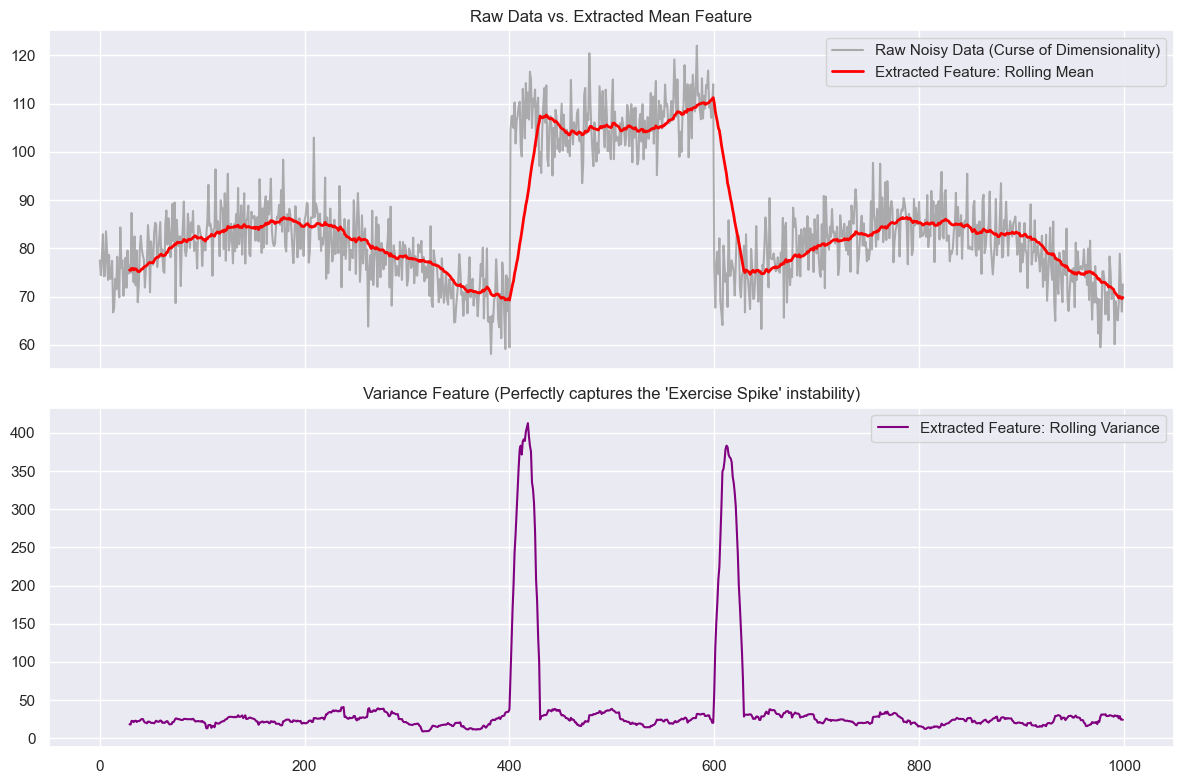

In [6]:
# Generate raw, noisy sensor data (e.g., heart rate over 1000 seconds)
np.random.seed(42)
time = np.arange(1000)
# Base heart rate + an exercise spike + random sensor noise
base_hr = 75 + np.sin(time / 100) * 10 
exercise_spike = np.where((time > 400) & (time < 600), 40, 0)
noise = np.random.normal(0, 5, 1000)
raw_hr = base_hr + exercise_spike + noise

df_sensor = pd.DataFrame({'Time': time, 'Raw_HeartRate': raw_hr})

# --- FEATURE EXTRACTION ---
window_size = 30 # 30-second rolling window
df_sensor['Extracted_Mean'] = df_sensor['Raw_HeartRate'].rolling(window=window_size).mean()
df_sensor['Extracted_Variance'] = df_sensor['Raw_HeartRate'].rolling(window=window_size).var()
df_sensor['Extracted_Max'] = df_sensor['Raw_HeartRate'].rolling(window=window_size).max()

# Visualizing the Extraction
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_sensor['Time'], df_sensor['Raw_HeartRate'], color='gray', alpha=0.6, label='Raw Noisy Data (Curse of Dimensionality)')
axes[0].plot(df_sensor['Time'], df_sensor['Extracted_Mean'], color='red', linewidth=2, label='Extracted Feature: Rolling Mean')
axes[0].set_title("Raw Data vs. Extracted Mean Feature")
axes[0].legend()

axes[1].plot(df_sensor['Time'], df_sensor['Extracted_Variance'], color='purple', label='Extracted Feature: Rolling Variance')
axes[1].set_title("Variance Feature (Perfectly captures the 'Exercise Spike' instability)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2. Domain-Specific Transformation: Fast Fourier Transform (FFT)
**The Problem:** We are analyzing an audio signal or machinery vibration. The data looks like a completely random squiggle in the *Time Domain*. A standard machine learning model cannot read a "squiggle."

**The Extraction:** We use a Fourier Transform to move from the Time Domain to the *Frequency Domain*. This algorithm deconstructs the squiggle into its exact component frequencies, giving the model clear, numerical features to look at.

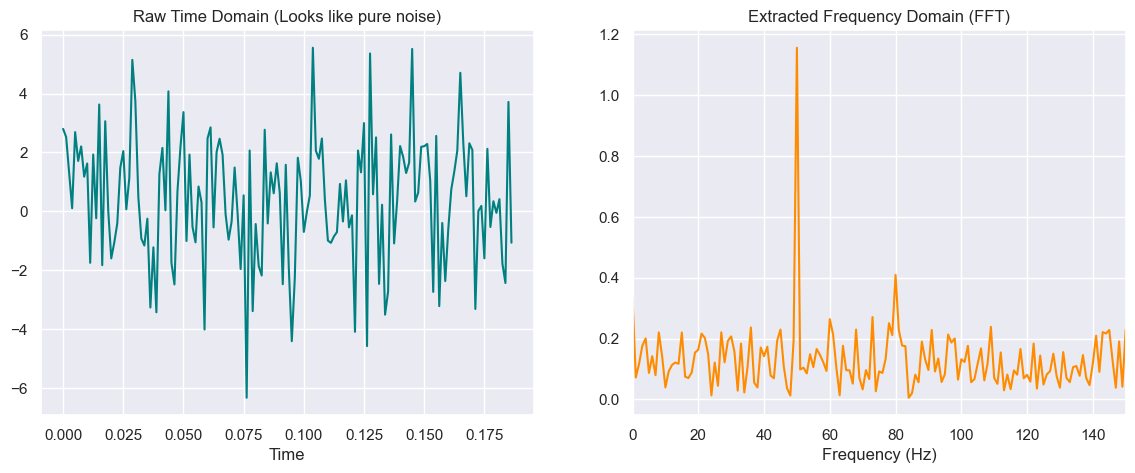

Observation: The FFT instantly slices through the noise and extracts two massive structural features: a spike at 50Hz and 80Hz. We can now feed these two simple numbers into a model instead of the 800 noisy data points!


In [7]:
# Generate a complex signal composed of two distinct frequencies heavily disguised by noise
N = 800     # Number of sample points
T = 1.0 / 800.0 # Sample spacing
x_time = np.linspace(0.0, N*T, N, endpoint=False)

# Signal = 10Hz wave + 50Hz wave + Heavy Noise
y_signal = np.sin(50.0 * 2.0*np.pi*x_time) + 0.5*np.sin(80.0 * 2.0*np.pi*x_time) + np.random.normal(0, 2, N)

# --- FEATURE EXTRACTION (FFT) ---
yf = fft(y_signal)
xf = fftfreq(N, T)[:N//2] # Get frequencies
amplitudes = 2.0/N * np.abs(yf[0:N//2]) # Get strength of frequencies

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x_time[:150], y_signal[:150], color='teal')
axes[0].set_title("Raw Time Domain (Looks like pure noise)")
axes[0].set_xlabel("Time")

axes[1].plot(xf, amplitudes, color='darkorange')
axes[1].set_title("Extracted Frequency Domain (FFT)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_xlim(0, 150)

plt.show()

print("Observation: The FFT instantly slices through the noise and extracts two massive structural features: a spike at 50Hz and 80Hz. We can now feed these two simple numbers into a model instead of the 800 noisy data points!")

### 3. Dimensionality Reduction: Principal Component Analysis (PCA)
**The Problem:** We have a dataset with dozens of highly correlated features (e.g., a car's 'weight', 'engine size', and 'horsepower' all basically tell us the same thing: it's a big car). Feeding all of these to a model causes multicollinearity and slows down training.

**The Extraction:** PCA creates new, orthogonal (uncorrelated) features that combine the variance of the original data. We project 10 dimensions down to 2, allowing us to capture the signal in a fraction of the space.

Original Shape: (500, 10) (10 Features)
Extracted Shape: (500, 2) (2 Features)
Variance Retained: 67.86%



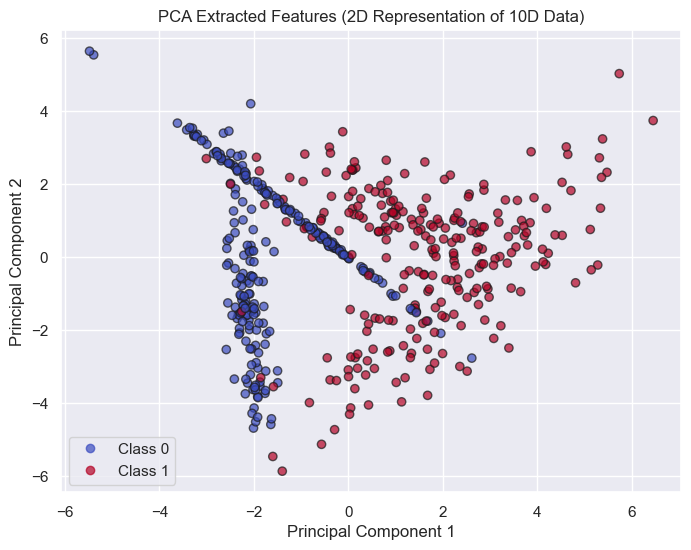

Observation: We threw away 8 columns of data, but as you can see in the plot, the 2 new Extracted Features perfectly separate the blue and red classes. The model will run much faster and be less prone to overfitting.


In [8]:
# Generate 10-Dimensional data where there are really only 2 underlying clusters (classes)
X_high_dim, y_labels = make_classification(
    n_samples=500, 
    n_features=10,       # 10 raw features
    n_informative=3,     # Only 3 hold real information
    n_redundant=5,       # 5 are just mathematical combinations of the 3 (redundant)
    n_classes=2, 
    random_state=42
)

# --- FEATURE EXTRACTION (PCA) ---
pca = PCA(n_components=2) # Compress 10 dimensions down to exactly 2
X_extracted = pca.fit_transform(X_high_dim)

print(f"Original Shape: {X_high_dim.shape} (10 Features)")
print(f"Extracted Shape: {X_extracted.shape} (2 Features)")
print(f"Variance Retained: {np.sum(pca.explained_variance_ratio_) * 100:.2f}%\n")

# Visualization
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_extracted[:, 0], X_extracted[:, 1], c=y_labels, cmap='coolwarm', alpha=0.7, edgecolor='k')
plt.title("PCA Extracted Features (2D Representation of 10D Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(handles=scatter.legend_elements()[0], labels=['Class 0', 'Class 1'])
plt.show()

print("Observation: We threw away 8 columns of data, but as you can see in the plot, the 2 new Extracted Features perfectly separate the blue and red classes. The model will run much faster and be less prone to overfitting.")

### 4. Learned Representations (Deep Learning - Conceptual)
In modern pipelines dealing with **unstructured data** (like an image of a dog), we don't manually calculate the mean pixel value. 

Instead, we pass the image through a **Convolutional Neural Network (CNN)**. The inner layers of the network act as automatic feature extractors, learning to identify edges, then textures, then shapes (like an ear or a nose), before passing those "learned features" to the final classification layer. 

*Trade-off:* While incredibly powerful, these extracted features are "black boxes"—a human cannot easily look at a CNN feature map and understand what mathematical transformation took place, unlike the clear logic of PCA or a Rolling Mean.